# Coarse-Graining Methods and Selection

## 0. Setup

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, SpectralClustering
from scipy.linalg import inv
from pygpcca import GPCCA
import warnings; warnings.filterwarnings('ignore')

# ── key parameter ─────────────────────────────────────────────────────────────
N_CLUSTERS = 4

# ── data paths ────────────────────────────────────────────────────────────────
A_samples  = np.load('data/England_Delta_50_EM/output/A_England_Delta.npy')   # (100, 50, 50)
Ne_samples = np.load('data/England_Delta_50_EM/output/Ne_England_Delta.npy')  # (100, 50)

n_samples, n_demes, _ = A_samples.shape
A  = A_samples.mean(0); A = A / A.sum(1, keepdims=True)
Ne = Ne_samples.mean(0)

print(f"n_demes={n_demes}, N_CLUSTERS={N_CLUSTERS}")
print(f"Ne mean={Ne.mean():.0f}, A_ii mean={np.diag(A).mean():.3f}")


n_demes=50, N_CLUSTERS=4
Ne mean=1481, A_ii mean=0.806


In [7]:
# shared helpers

def stationary(A):
    n = A.shape[0]; M = A.T - np.eye(n); M[-1] = 1
    b = np.zeros(n); b[-1] = 1
    return np.linalg.solve(M, b)

def timescales(A):
    ev = np.sort(np.abs(np.linalg.eigvals(A)))[::-1]
    return -1 / np.log(np.clip(ev[1:], 1e-12, 1-1e-12))

def coarse_A(labels, A, Ne, m):
    P = np.zeros((m, m))
    for k in range(m):
        dk = np.where(labels==k)[0]
        if not len(dk): P[k,k]=1; continue
        den = sum(A[i,j]*Ne[j] for i in dk for j in range(len(Ne)))
        for l in range(m):
            dl = np.where(labels==l)[0]
            P[k,l] = sum(A[i,j]*Ne[j] for i in dk for j in dl)/den if den else 0
    P = np.clip(P,0,None); return P / P.sum(1, keepdims=True)

def int_flow(labels, A, m):
    out = []
    for k in range(m):
        d = np.where(labels==k)[0]
        out.append(float(A[np.ix_(d,d)].sum(1).mean()) if len(d)>1 else 0.)
    return out

def wf_step(p, A, Ne):
    pm = A @ p; pn = np.zeros_like(p)
    for i in range(len(p)):
        n = max(int(round(Ne[i])),1)
        pn[i] = np.random.binomial(n, float(np.clip(pm[i],0,1))) / n
    return pn

def wf_traj(p0, A, Ne, T):
    p = p0.copy(); out = [p.copy()]
    for _ in range(T): p = wf_step(p,A,Ne); out.append(p.copy())
    return np.array(out)

def proj_fuzzy(traj, chi, Ne, m):
    out = np.zeros((len(traj), m))
    for k in range(m):
        w = chi[:,k]*Ne
        if w.sum()>0: out[:,k] = traj @ w / w.sum()
    return out

def proj_hard(traj, labels, Ne, m):
    out = np.zeros((len(traj), m))
    for k in range(m):
        d = np.where(labels==k)[0]
        if not len(d): continue
        w = Ne[d]/Ne[d].sum(); out[:,k] = traj[:,d] @ w
    return out

print("helpers ready")


helpers ready


## 1. GPCCA

In [8]:
g = GPCCA(A)
g.optimize(m=N_CLUSTERS)

chi   = g.memberships
P_g   = np.clip(g.coarse_grained_transition_matrix, 0, None)
P_g   = P_g / P_g.sum(1, keepdims=True)
Ne_g  = chi.T @ Ne
lbl_g = np.argmax(chi, 1)

print("Coarse A (GPCCA):"); print(np.round(P_g, 4))
print("\nCluster sizes:", [(lbl_g==k).sum() for k in range(N_CLUSTERS)])
print("Internal flows:", [round(f,3) for f in int_flow(lbl_g, A, N_CLUSTERS)])
print("\nTimescales:")
ts_f = timescales(A); ts_g = timescales(P_g)
for k in range(min(N_CLUSTERS-1, 4)):
    print(f"  tau_{k+2}: full={ts_f[k]:.2f}  GPCCA={ts_g[k]:.2f}")


Coarse A (GPCCA):
[[0.9305 0.0047 0.0273 0.0375]
 [0.     0.8796 0.0744 0.0461]
 [0.0433 0.0048 0.9104 0.0416]
 [0.0232 0.0058 0.0202 0.9509]]

Cluster sizes: [np.int64(8), np.int64(0), np.int64(7), np.int64(35)]
Internal flows: [0.915, 0.0, 0.894, 0.951]

Timescales:
  tau_2: full=11.04  GPCCA=10.97
  tau_3: full=8.92  GPCCA=8.09
  tau_4: full=8.14  GPCCA=7.48


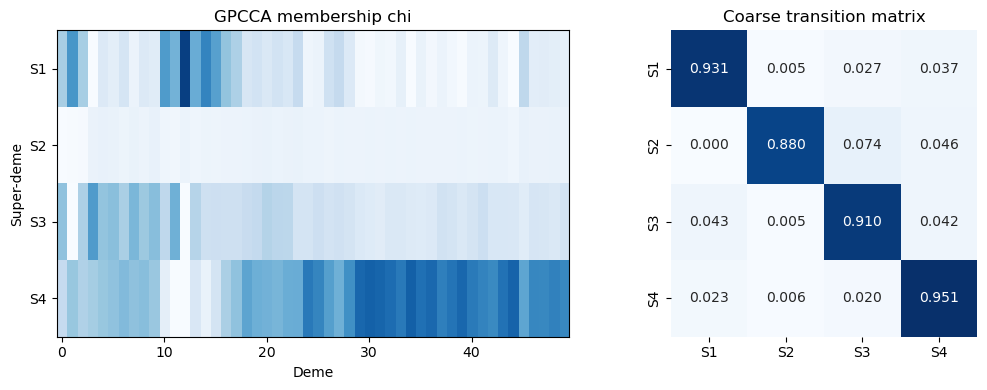

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.imshow(chi.T, aspect='auto', cmap='Blues', vmin=0, vmax=1)
ax.set_xlabel('Deme'); ax.set_ylabel('Super-deme')
ax.set_yticks(range(N_CLUSTERS))
ax.set_yticklabels([f'S{k+1}' for k in range(N_CLUSTERS)])
ax.set_title('GPCCA membership chi')

ax = axes[1]
sns.heatmap(P_g, ax=ax, annot=True, fmt='.3f', cmap='Blues',
            square=True, cbar=False,
            xticklabels=[f'S{k+1}' for k in range(N_CLUSTERS)],
            yticklabels=[f'S{k+1}' for k in range(N_CLUSTERS)])
ax.set_title('Coarse transition matrix')
plt.tight_layout(); plt.show()


## 2. Escape Hitting Distribution

In [68]:
NE_SCALE_ESCAPE   = Ne.mean() / 5.0
N_TRIALS   = 500
THRESHOLD  = 0.5

Ne_sc = np.maximum(Ne / NE_SCALE_ESCAPE, 1.0)

def first_hit(origin, A, Ne, thr=0.5, max_gen=2000):
    p = np.zeros(len(Ne)); p[origin] = 1./max(Ne[origin],1.)
    for _ in range(max_gen):
        p = wf_step(p, A, Ne)
        hits = np.where(p > thr)[0]
        if len(hits): return int(hits[np.argmax(p[hits])])
        if p.sum() < 1e-9: return -1
    return -1

H = np.zeros((n_demes, n_demes))
for origin in range(n_demes):
    counts = np.zeros(n_demes); lost = 0
    for _ in range(N_TRIALS):
        d = first_hit(origin, A, Ne_sc, THRESHOLD)
        if d >= 0: counts[d] += 1
        else: lost += 1
    tot = counts.sum()
    H[origin] = counts/tot if tot>0 else 0.
    if (origin+1) % 10 == 0:
        print(f"  deme {origin+1}/50  loss={lost/N_TRIALS:.2f}")
print("done")


  deme 10/50  loss=0.68
  deme 20/50  loss=0.87
  deme 30/50  loss=0.91
  deme 40/50  loss=0.83
  deme 50/50  loss=0.71
done


In [69]:
# zero diagonal, renormalise, cluster
H_esc = H.copy(); np.fill_diagonal(H_esc, 0.)
rs = H_esc.sum(1, keepdims=True); rs[rs<1e-9]=1.
H_esc /= rs

km = KMeans(n_clusters=N_CLUSTERS, n_init=50, random_state=42).fit(H_esc)
lbl_e = km.labels_
# reorder by internal flow
order = np.argsort(int_flow(lbl_e, A, N_CLUSTERS))
remap = {o:n for n,o in enumerate(order)}
lbl_e = np.array([remap[l] for l in lbl_e])

P_e   = coarse_A(lbl_e, A, Ne, N_CLUSTERS)
Ne_e  = np.array([(Ne[lbl_e==k].sum() if (lbl_e==k).sum()>0 else 1.)
                   for k in range(N_CLUSTERS)])

print("Cluster sizes:", [(lbl_e==k).sum() for k in range(N_CLUSTERS)])
print("Internal flows:", [round(f,3) for f in int_flow(lbl_e, A, N_CLUSTERS)])


Cluster sizes: [np.int64(2), np.int64(4), np.int64(23), np.int64(21)]
Internal flows: [0.751, 0.821, 0.916, 0.929]


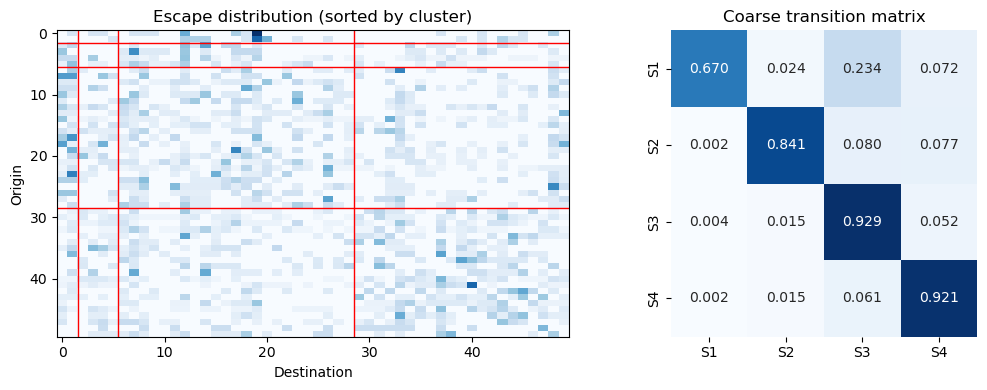

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
oi = np.argsort(lbl_e)
ax.imshow(H_esc[np.ix_(oi,oi)], aspect='auto', cmap='Blues')
ax.set_title('Escape distribution (sorted by cluster)')
ax.set_xlabel('Destination'); ax.set_ylabel('Origin')
bounds = np.cumsum([(lbl_e==k).sum() for k in range(N_CLUSTERS)])[:-1]
for b in bounds: ax.axhline(b-.5,color='r',lw=1); ax.axvline(b-.5,color='r',lw=1)

ax = axes[1]
sns.heatmap(P_e, ax=ax, annot=True, fmt='.3f', cmap='Blues',
            square=True, cbar=False,
            xticklabels=[f'S{k+1}' for k in range(N_CLUSTERS)],
            yticklabels=[f'S{k+1}' for k in range(N_CLUSTERS)])
ax.set_title('Coarse transition matrix')
plt.tight_layout(); plt.show()


## 3. MFPT

In [71]:
pi   = stationary(A)
Pi   = np.tile(pi, (n_demes,1))
Z    = inv(np.eye(n_demes) - A + Pi)

T = np.zeros((n_demes, n_demes))
for i in range(n_demes):
    for j in range(n_demes):
        if i!=j: T[i,j] = (Z[j,j]-Z[i,j])/pi[j]
T = np.clip(T, 0, np.percentile(T[T>0], 95))

tau = np.median(T[T>0])
S   = np.exp(-(T+T.T)/(2*tau)); np.fill_diagonal(S,0.)

sc = SpectralClustering(n_clusters=N_CLUSTERS, affinity='precomputed',
                        n_init=50, random_state=42).fit(S)
lbl_m = sc.labels_
order = np.argsort(int_flow(lbl_m, A, N_CLUSTERS))
remap = {o:n for n,o in enumerate(order)}
lbl_m = np.array([remap[l] for l in lbl_m])

P_m   = coarse_A(lbl_m, A, Ne, N_CLUSTERS)
Ne_m  = np.array([(Ne[lbl_m==k].sum() if (lbl_m==k).sum()>0 else 1.)
                   for k in range(N_CLUSTERS)])

print("Cluster sizes:", [(lbl_m==k).sum() for k in range(N_CLUSTERS)])
print("Internal flows:", [round(f,3) for f in int_flow(lbl_m, A, N_CLUSTERS)])


Cluster sizes: [np.int64(11), np.int64(8), np.int64(18), np.int64(13)]
Internal flows: [0.864, 0.883, 0.907, 0.932]


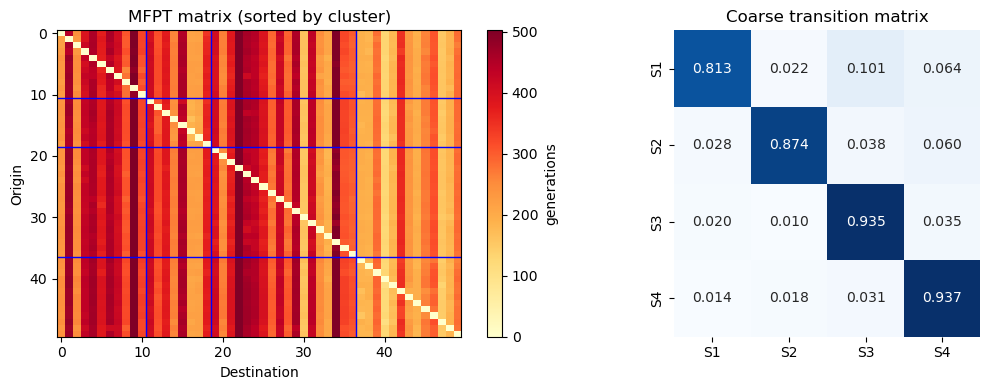

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
oi = np.argsort(lbl_m)
im = ax.imshow(T[np.ix_(oi,oi)], aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='generations')
ax.set_title('MFPT matrix (sorted by cluster)')
ax.set_xlabel('Destination'); ax.set_ylabel('Origin')
bounds = np.cumsum([(lbl_m==k).sum() for k in range(N_CLUSTERS)])[:-1]
for b in bounds: ax.axhline(b-.5,color='b',lw=1); ax.axvline(b-.5,color='b',lw=1)

ax = axes[1]
sns.heatmap(P_m, ax=ax, annot=True, fmt='.3f', cmap='Blues',
            square=True, cbar=False,
            xticklabels=[f'S{k+1}' for k in range(N_CLUSTERS)],
            yticklabels=[f'S{k+1}' for k in range(N_CLUSTERS)])
ax.set_title('Coarse transition matrix')
plt.tight_layout(); plt.show()


## 4. Validation

In [73]:
N_STEPS = 200
N_SIMS  = 60

methods = {
    'GPCCA':  (lbl_g, Ne_g,  P_g, 'fuzzy', chi),
    'Escape': (lbl_e, Ne_e,  P_e, 'hard',  None),
    'MFPT':   (lbl_m, Ne_m,  P_m, 'hard',  None),
}

results = {}
for ic, p0_fn in [
    ('uniform',   lambda: np.full(n_demes, 0.1)),
    ('localised', lambda: np.concatenate([[0.5], np.zeros(n_demes-1)])),
]:
    results[ic] = {}
    for name, (lbl, Ne_c, P_c, ptype, ch) in methods.items():
        tp, tc = [], []
        p0_full = p0_fn()
        if ptype=='fuzzy':
            p0c = np.array([np.dot(ch[:,k]*Ne, p0_full)/max((ch[:,k]*Ne).sum(),1e-9)
                            for k in range(N_CLUSTERS)])
        else:
            p0c = np.array([(Ne[lbl==k]*p0_full[lbl==k]).sum()/max(Ne[lbl==k].sum(),1e-9)
                            if (lbl==k).sum()>0 else 0.1 for k in range(N_CLUSTERS)])
        for _ in range(N_SIMS):
            tf = wf_traj(p0_fn(), A, Ne, N_STEPS)
            tp.append(proj_fuzzy(tf,ch,Ne,N_CLUSTERS) if ptype=='fuzzy'
                      else proj_hard(tf,lbl,Ne,N_CLUSTERS))
            tc.append(wf_traj(p0c.copy(), P_c, Ne_c, N_STEPS))
        results[ic][name] = {'proj': np.array(tp), 'coarse': np.array(tc)}
    print(f"done: {ic}")


done: uniform
done: localised


In [74]:
# variance ratio table
t_check = [20, 100, N_STEPS]
for ic in ['uniform','localised']:
    print(f"\n{ic.upper()}")
    print(f"{'':>10}" + "".join(f"  t={t:>4}" for t in t_check))
    for name in methods:
        d = results[ic][name]; p = d['proj']; c = d['coarse']
        row = f"{name:>10}"
        for t in t_check:
            vr = np.nanmean([c[:,t,k].var()/p[:,t,k].var()
                             if p[:,t,k].var()>1e-10 else np.nan
                             for k in range(N_CLUSTERS)])
            row += f"  {vr:>6.3f}"
        print(row)
print("\nideal = 1.0")



UNIFORM
            t=  20  t= 100  t= 200
     GPCCA   2.346   1.052   0.835
    Escape   0.939   0.533   0.702
      MFPT   0.973   0.813   0.730

LOCALISED
            t=  20  t= 100  t= 200
     GPCCA   1.073   0.362   0.384
    Escape   0.527   0.579   0.443
      MFPT   0.788   0.859   0.745

ideal = 1.0


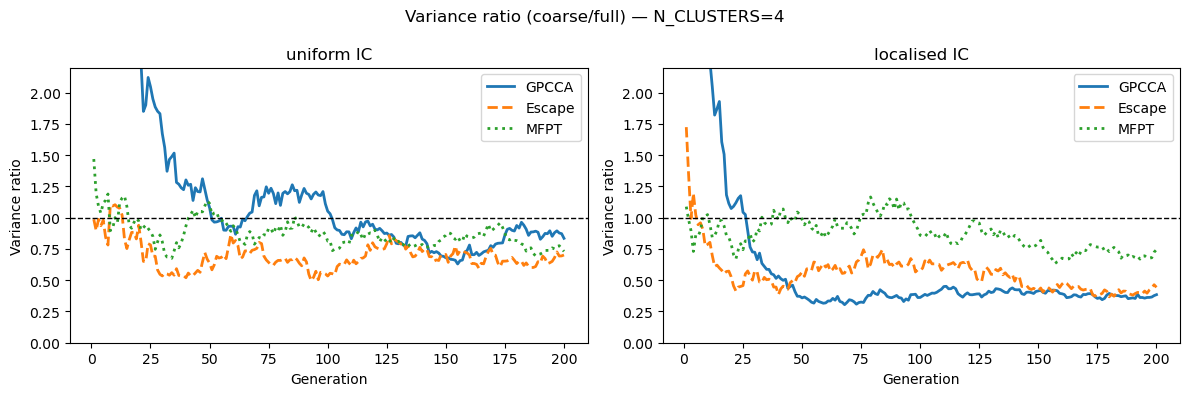

In [75]:
# variance ratio over time
t_arr = np.arange(N_STEPS+1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ls = {'GPCCA':'-','Escape':'--','MFPT':':'}

for col, ic in enumerate(['uniform','localised']):
    ax = axes[col]
    for name in methods:
        d = results[ic][name]; p = d['proj']; c = d['coarse']
        vr = [np.nanmean([c[:,t,k].var()/p[:,t,k].var()
                          if p[:,t,k].var()>1e-10 else np.nan
                          for k in range(N_CLUSTERS)])
              for t in range(N_STEPS+1)]
        ax.plot(t_arr, vr, lw=2, ls=ls[name], label=name)
    ax.axhline(1., color='k', lw=1, ls='--')
    ax.set_xlabel('Generation'); ax.set_ylabel('Variance ratio')
    ax.set_title(f'{ic} IC'); ax.set_ylim(0, 2.2)
    ax.legend()

plt.suptitle(f'Variance ratio (coarse/full) — N_CLUSTERS={N_CLUSTERS}')
plt.tight_layout(); plt.show()


## 5. Summary Comparison

In [76]:
from itertools import permutations

def best_agreement(l1, l2, m):
    return max((l1==np.array([p[x] for x in l2])).mean()
               for p in permutations(range(m)))

# timescales
print("Timescales:")
print(f"{'':>8}" + f"{'full':>8}" +
      "".join(f"{n:>10}" for n in methods))
ts_all = {n: timescales(P) for n,(lbl,Ne_c,P,*_) in methods.items()}
for k in range(min(N_CLUSTERS-1,5)):
    row = f"  tau_{k+2}  {timescales(A)[k]:>7.2f}"
    for n in methods: row += f"  {ts_all[n][k]:>8.2f}"
    print(row)

# internal flow
print("\nInternal flow:")
for n,(lbl,*_) in methods.items():
    f = int_flow(lbl,A,N_CLUSTERS)
    print(f"  {n:>10}: {[round(x,3) for x in f]}  mean={np.mean(f):.3f}")

# cluster agreement
print("\nCluster agreement:")
lbls = {n:lbl for n,(lbl,*_) in methods.items()}
pairs = [('GPCCA','Escape'),('GPCCA','MFPT'),('Escape','MFPT')]
for m1,m2 in pairs:
    print(f"  {m1} vs {m2}: {best_agreement(lbls[m1],lbls[m2],N_CLUSTERS):.1%}")


Timescales:
            full     GPCCA    Escape      MFPT
  tau_2    11.04     10.97      7.15     10.00
  tau_3     8.92      8.09      5.22      6.64
  tau_4     8.14      7.48      2.46      4.33

Internal flow:
       GPCCA: [0.915, 0.0, 0.894, 0.951]  mean=0.690
      Escape: [0.751, 0.821, 0.916, 0.929]  mean=0.854
        MFPT: [0.864, 0.883, 0.907, 0.932]  mean=0.896

Cluster agreement:
  GPCCA vs Escape: 64.0%
  GPCCA vs MFPT: 62.0%
  Escape vs MFPT: 56.0%


In [77]:
from scipy.linalg import schur
S_SEL    = 0.05            # selection coefficient to test
N_STEPS  = 200
N_SIMS   = 2000
POST_SUB = 30             # posterior samples to average diagnostics over (<=100)
 
rng = np.random.default_rng(0)
 
# reload the posterior so we can evaluate across samples, not just the mean
A_samples  = np.load('data/England_Delta_50_EM/output/A_England_Delta.npy')
Ne_samples = np.load('data/England_Delta_50_EM/output/Ne_England_Delta.npy')
n_post = A_samples.shape[0]
 

In [78]:
def wf_step_sel(p, A, Ne, s):
    pm = A @ p
    pm = pm + s * pm * (1 - pm)          # deterministic selection shift
    pm = np.clip(pm, 0, 1)
    pn = np.zeros_like(p)
    for i in range(len(p)):
        n = max(int(round(Ne[i])), 1)
        pn[i] = np.random.binomial(n, float(pm[i])) / n
    return pn
 
 
def wf_traj_sel(p0, A, Ne, T, s):
    p = p0.copy(); out = [p.copy()]
    for _ in range(T):
        p = wf_step_sel(p, A, Ne, s)
        out.append(p.copy())
    return np.array(out)
 
 
# build the explicit S matrices (m x n) from your labels / memberships,
# so the diagnostics can use S directly. Stationary/Ne-weighted rows.
def S_from_labels(labels, Ne, m):
    S = np.zeros((m, len(Ne)))
    for k in range(m):
        idx = labels == k
        if idx.sum() == 0:
            continue
        w = Ne[idx]
        S[k, idx] = w / w.sum()
    return S
 
 
def S_from_chi(chi, Ne, m):
    S = np.zeros((m, len(Ne)))
    for k in range(m):
        w = chi[:, k] * Ne
        if w.sum() > 0:
            S[k] = w / w.sum()
    return S
 

In [79]:
def schur_heatmaps(A, m):
    import matplotlib.pyplot as plt
    T, Z = schur(A.T, output='real')
    ev = np.diag(T)
    order = np.argsort(-np.abs(ev))
    X = Z[:, order[:m]]
    fig, axes = plt.subplots(1, m, figsize=(2.6 * m, 3.2))
    for k in range(m):
        v = X[:, k]
        axes[k].imshow(v.reshape(-1, 1), aspect='auto', cmap='RdBu',
                       vmin=-np.abs(v).max(), vmax=np.abs(v).max())
        axes[k].set_title(f'Schur {k}'); axes[k].set_xticks([])
    plt.tight_layout(); plt.savefig('schur_vectors.png', dpi=120)
    plt.show()
    return X

In [80]:
def selection_error(S, s, n_post_sub, n_sims=20):
    ratios = []
    for i in range(n_post_sub):
        Ai = A_samples[i] / A_samples[i].sum(1, keepdims=True)
        Nei = np.maximum(Ne_samples[i] / NE_SCALE, 1.0)
        sel_err, sig = [], []
        for _ in range(n_sims):
            f0 = rng.uniform(0.2, 0.8, Ai.shape[0])
            traj = wf_traj_sel(f0, Ai, Nei, N_STEPS, s)
            for f in traj[::10]:
                true_sel = S @ (s * f * (1 - f))
                fp = S @ f
                sel_err.append(np.linalg.norm(true_sel - s * fp * (1 - fp)))
                sig.append(np.linalg.norm(true_sel))
        ratios.append(np.mean(sel_err) / (np.mean(sig) + 1e-12))
    return np.array(ratios)

In [81]:
def mismatch(labels, chi_or_none, P_c, Ne_c, ptype, s, n_sims=N_SIMS):
    Ne_val = Ne / NE_SCALE
    errs = []
    for _ in range(n_sims):
        f0 = rng.uniform(0.2, 0.8, n_demes)
        full = wf_traj_sel(f0, A, Ne_val, N_STEPS, s)
        if ptype == 'fuzzy':
            f_true = proj_fuzzy(full, chi_or_none, Ne_val, N_CLUSTERS)
            p0c = f_true[0].copy()
        else:
            f_true = proj_hard(full, labels, Ne_val, N_CLUSTERS)
            p0c = f_true[0].copy()
        f_sim = wf_traj_sel(p0c, P_c, Ne_c, N_STEPS, s)
        errs.append(np.mean((f_true - f_sim) ** 2, axis=1))
    return np.array(errs)
 

In [82]:
def learn_linear_S(m, s, steps=800, lr=5e-3, batch=12, beta=0.5,
                   grad_clip=5.0, patience=150):
    """
    Learn a column-stochastic-ish S minimising one-step consistency loss,
    regularised against cluster collapse.
 
    Fixes over the naive version:
      - mini-batch of `batch` trajectories per step (kills the 1-sample noise
        that produced loss spikes)
      - gradient normalised then clipped to `grad_clip` (no more nan blowups)
      - non-finite guard: a bad step is skipped, not propagated
      - anti-collapse penalty `beta * balance`: the trivial [n,0,0,...] map is
        no longer optimal, so all m super-demes stay populated
      - EMA-logged loss + early stop so you can see real convergence
 
    Loss per trajectory:
        sum_t || S f(t+1) - [Ap (S f(t)) + s (S f(t))(1-S f(t))] ||^2
      + beta * collapse_penalty(S)
    """
    n = A.shape[0]
    S = rng.normal(0, 0.1, (m, n))
    best_S, best = S.copy(), np.inf
    ema, since_improve = None, 0
 
    def normed(S):
        Sn = np.abs(S)
        return Sn / (Sn.sum(0, keepdims=True) + 1e-12)   # columns sum to 1
 
    for step in range(steps):
        g = np.zeros_like(S)
        data_loss = 0.0
        Scol = normed(S)                                  # column-stochastic view
        for _ in range(batch):
            i = rng.integers(min(POST_SUB, n_post))
            Ai = A_samples[i] / A_samples[i].sum(1, keepdims=True)
            Nei = np.maximum(Ne_samples[i] / NE_SCALE, 1.0)
            f0 = rng.uniform(0.2, 0.8, n)
            full = wf_traj_sel(f0, Ai, Nei, N_STEPS, s)
            Ap = coarse_A(np.argmax(Scol, 0), Ai, Nei, m)
            for t in range(len(full) - 1):
                ft, ft1 = full[t], full[t + 1]
                z = np.clip(S @ ft, 0, 1)
                pred = np.clip(Ap @ z + s * z * (1 - z), 0, 1)
                resid = np.clip(S @ ft1, 0, 1) - pred
                data_loss += np.sum(resid ** 2)
                g += 2 * np.outer(resid, ft1)
        denom = batch * N_STEPS
        g /= denom; data_loss /= denom
 
        # ---- anti-collapse penalty ----
        # total weight each super-deme captures; want ~ equal across the m.
        w = np.abs(S).sum(1)                              # (m,)
        target = w.sum() / m
        bal = np.sum((w - target) ** 2) / (target ** 2 + 1e-12)
        gbal = beta * 2 * (w - target)[:, None] * np.sign(S) / (target ** 2 + 1e-12)
        g = g + gbal
        loss = data_loss + beta * bal
 
        if not np.isfinite(loss):
            S = best_S + rng.normal(0, 0.05, S.shape)     # recover from blowup
            continue
 
        gn = np.linalg.norm(g)
        if gn > grad_clip:
            g *= grad_clip / gn
        S -= lr * g
 
        ema = loss if ema is None else 0.9 * ema + 0.1 * loss
        if loss < best - 1e-6:
            best, best_S, since_improve = loss, S.copy(), 0
        else:
            since_improve += 1
        if step % 100 == 0:
            print(f"  [linear S] step {step:4d}  loss {loss:.4e}  ema {ema:.4e}")
        if since_improve > patience:
            print(f"  [linear S] early stop at step {step} (no improvement)")
            break
 
    return normed(best_S)
 

== 1. Schur vector heatmaps ==


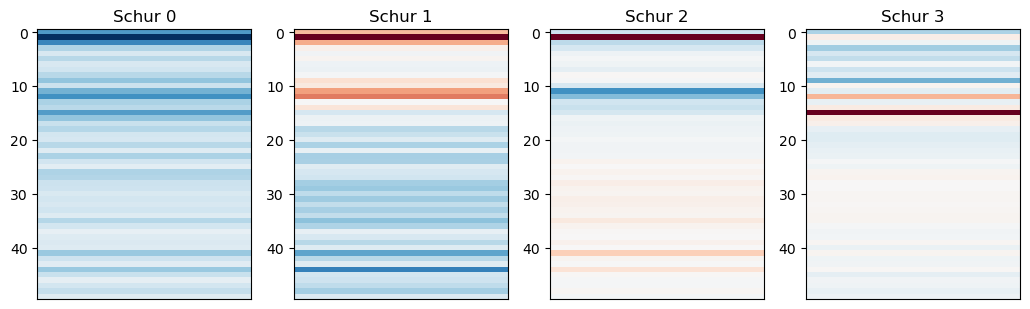


== 2. selection-error ratio across posterior (lower = more robust) ==
  GPCCA  : 0.639 +/- 0.050
  Escape : 0.570 +/- 0.045
  MFPT   : 0.636 +/- 0.052

== 3. trajectory mismatch (final-gen MSE) at s=0 and s=S_SEL ==
  GPCCA   s=0.0 : 2.9038e-01
  GPCCA   s=0.05: 1.1072e-03
  Escape  s=0.0 : 2.8744e-01
  Escape  s=0.05: 7.9356e-04
  MFPT    s=0.0 : 2.8115e-01
  MFPT    s=0.05: 4.4414e-04

== 4. learned linear S ==
  [linear S] step    0  loss 1.8905e-02  ema 1.8905e-02
  [linear S] step  100  loss 2.1654e-02  ema 1.8395e-02
  [linear S] step  200  loss 1.8872e-02  ema 2.3535e-02
  [linear S] early stop at step 206 (no improvement)
  learned s=0.05: 5.3542e-04
  learned cluster sizes: [12, 14, 10, 14]


In [83]:
if __name__ == "__main__" or True:
    print("== 1. Schur vector heatmaps ==")
    schur_heatmaps(A, N_CLUSTERS)
 
    print("\n== 2. selection-error ratio across posterior (lower = more robust) ==")
    S_g = S_from_chi(chi, Ne / NE_SCALE, N_CLUSTERS)
    S_e = S_from_labels(lbl_e, Ne / NE_SCALE, N_CLUSTERS)
    S_m = S_from_labels(lbl_m, Ne / NE_SCALE, N_CLUSTERS)
    for name, S in [("GPCCA", S_g), ("Escape", S_e), ("MFPT", S_m)]:
        r = selection_error(S, S_SEL, POST_SUB)
        print(f"  {name:7s}: {r.mean():.3f} +/- {r.std():.3f}")
 
    print("\n== 3. trajectory mismatch (final-gen MSE) at s=0 and s=S_SEL ==")
    cfg = {
        'GPCCA':  (lbl_g, chi,  P_g, (chi.T @ (Ne / NE_SCALE)), 'fuzzy'),
        'Escape': (lbl_e, None, P_e, None, 'hard'),
        'MFPT':   (lbl_m, None, P_m, None, 'hard'),
    }
    for name, (lbl, ch, P_c, Ne_c, pt) in cfg.items():
        if Ne_c is None:
            Ne_c = np.array([(Ne[lbl == k] / NE_SCALE).sum()
                             if (lbl == k).sum() > 0 else 1.0
                             for k in range(N_CLUSTERS)])
        for s_val in [0.0, S_SEL]:
            e = mismatch(lbl, ch, P_c, Ne_c, pt, s_val)
            print(f"  {name:7s} s={s_val:<4}: {e[:, -1].mean():.4e}")
 
    print("\n== 4. learned linear S ==")
    S_lin = learn_linear_S(N_CLUSTERS, S_SEL)
    lbl_lin = np.argmax(S_lin, 0)
    Ne_lin = np.array([(Ne[lbl_lin == k] / NE_SCALE).sum()
                       if (lbl_lin == k).sum() > 0 else 1.0
                       for k in range(N_CLUSTERS)])
    P_lin = coarse_A(lbl_lin, A, Ne / NE_SCALE, N_CLUSTERS)
    e = mismatch(lbl_lin, None, P_lin, Ne_lin, 'hard', S_SEL)
    print(f"  learned s={S_SEL}: {e[:, -1].mean():.4e}")
    print(f"  learned cluster sizes: {[int((lbl_lin==k).sum()) for k in range(N_CLUSTERS)]}")


plotting trajectory mismatch at s=S_SEL ...


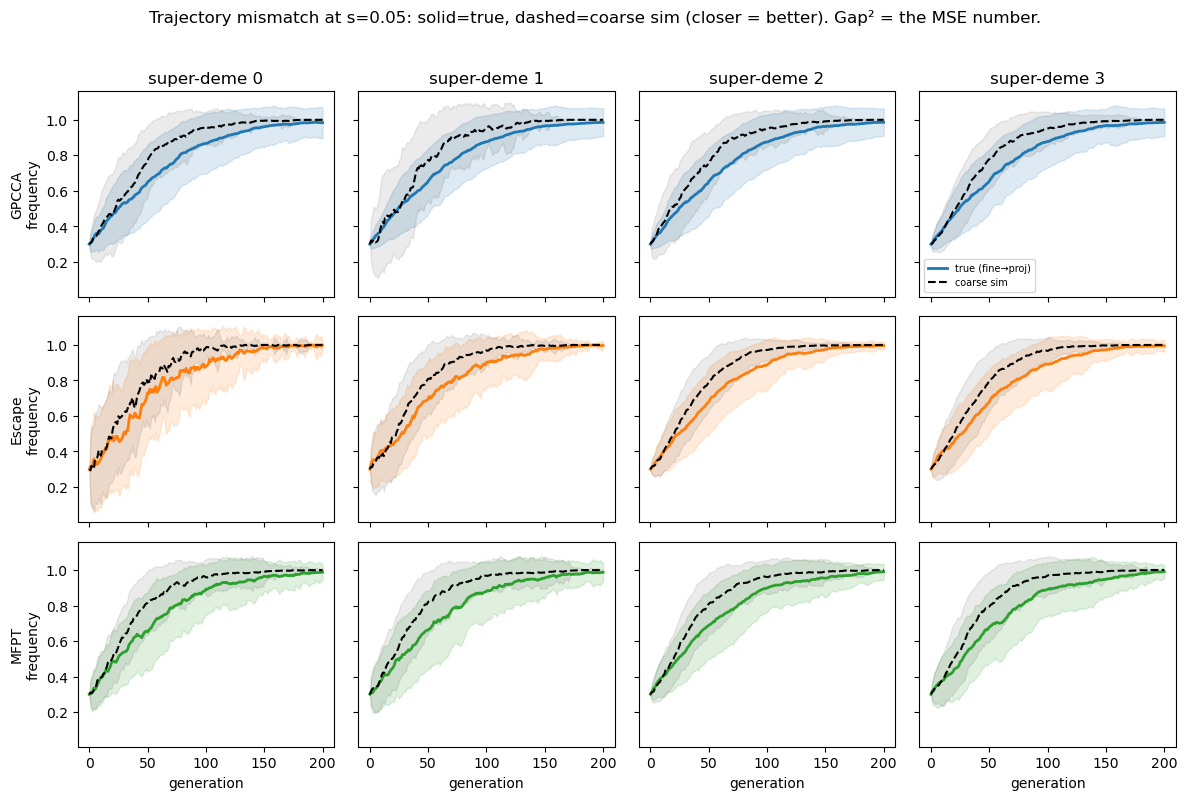

plotting trajectory mismatch at s=0 ...


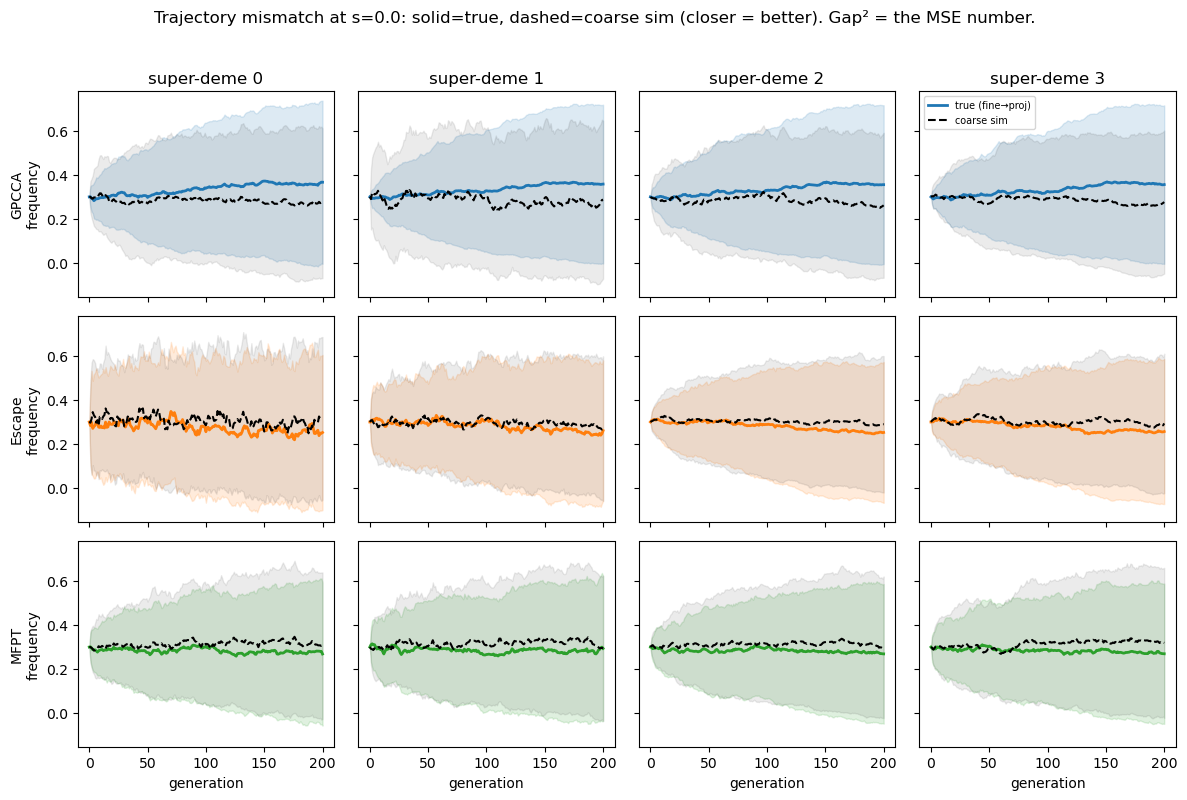

plotting selection-error decomposition ...


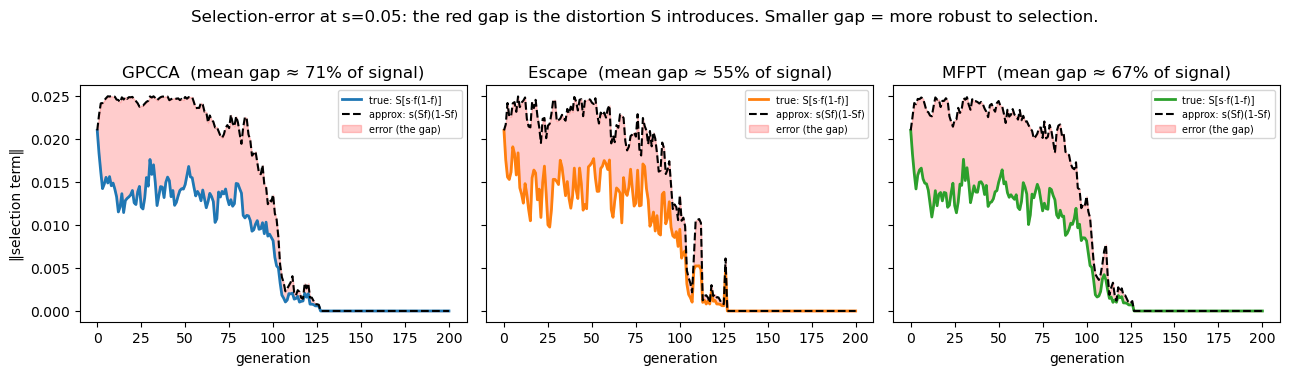

In [84]:
Ne_val = Ne / NE_SCALE
COLORS = {'GPCCA': '#1f77b4', 'Escape': '#ff7f0e', 'MFPT': '#2ca02c'}


def trajectory_plot(s, n_sims=100, T=200):
    cfg = {
        'GPCCA':  (lbl_g, chi,  P_g, 'fuzzy'),
        'Escape': (lbl_e, None, P_e, 'hard'),
        'MFPT':   (lbl_m, None, P_m, 'hard'),
    }
    fig, axes = plt.subplots(len(cfg), N_CLUSTERS,
                             figsize=(3 * N_CLUSTERS, 2.6 * len(cfg)),
                             sharex=True, sharey=True)

    f0 = np.full(n_demes, 0.3)                      # fixed IC for clarity
    for row, (name, (lbl, ch, P_c, pt)) in enumerate(cfg.items()):
        if pt == 'fuzzy':
            Ne_c = ch.T @ Ne_val
        else:
            Ne_c = np.array([Ne_val[lbl == k].sum() if (lbl == k).sum() > 0
                             else 1.0 for k in range(N_CLUSTERS)])

        true_all, sim_all = [], []
        for _ in range(n_sims):
            full = wf_traj_sel(f0, A, Ne_val, T, s)
            f_true = (proj_fuzzy(full, ch, Ne_val, N_CLUSTERS) if pt == 'fuzzy'
                      else proj_hard(full, lbl, Ne_val, N_CLUSTERS))
            f_sim = wf_traj_sel(f_true[0].copy(), P_c, Ne_c, T, s)
            true_all.append(f_true); sim_all.append(f_sim)
        true_all = np.array(true_all); sim_all = np.array(sim_all)
        tmu, tsd = true_all.mean(0), true_all.std(0)
        smu, ssd = sim_all.mean(0), sim_all.std(0)
        gen = np.arange(T + 1)

        for k in range(N_CLUSTERS):
            ax = axes[row, k]
            ax.plot(gen, tmu[:, k], color=COLORS[name], lw=2, label='true (fine→proj)')
            ax.fill_between(gen, tmu[:, k] - tsd[:, k], tmu[:, k] + tsd[:, k],
                            color=COLORS[name], alpha=0.15)
            ax.plot(gen, smu[:, k], color='k', lw=1.5, ls='--', label='coarse sim')
            ax.fill_between(gen, smu[:, k] - ssd[:, k], smu[:, k] + ssd[:, k],
                            color='k', alpha=0.08)
            if row == 0:
                ax.set_title(f'super-deme {k}')
            if k == 0:
                ax.set_ylabel(f'{name}\nfrequency')
            if row == len(cfg) - 1:
                ax.set_xlabel('generation')
            if row == 0 and k == N_CLUSTERS - 1:
                ax.legend(fontsize=7, loc='best')
    fig.suptitle(f'Trajectory mismatch at s={s}: solid=true, dashed=coarse sim '
                 f'(closer = better). Gap² = the MSE number.', y=1.02)
    plt.tight_layout()
    plt.savefig(f'traj_mismatch_s{s}.png', dpi=130, bbox_inches='tight')
    plt.show()


def selection_error_plot(s, T=200):
    Ss = {'GPCCA': S_from_chi(chi, Ne_val, N_CLUSTERS),
          'Escape': S_from_labels(lbl_e, Ne_val, N_CLUSTERS),
          'MFPT': S_from_labels(lbl_m, Ne_val, N_CLUSTERS)}

    f0 = np.full(n_demes, 0.3)
    full = wf_traj_sel(f0, A, Ne_val, T, s)
    gen = np.arange(T + 1)

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
    for ax, (name, S) in zip(axes, Ss.items()):
        true_term = np.array([np.linalg.norm(S @ (s * f * (1 - f))) for f in full])
        fp = (S @ full.T).T
        approx_term = np.array([np.linalg.norm(s * z * (1 - z)) for z in fp])
        ax.plot(gen, true_term, color=COLORS[name], lw=2, label='true: S[s·f(1-f)]')
        ax.plot(gen, approx_term, color='k', lw=1.5, ls='--', label='approx: s(Sf)(1-Sf)')
        ax.fill_between(gen, np.minimum(true_term, approx_term),
                        np.maximum(true_term, approx_term),
                        color='red', alpha=0.2, label='error (the gap)')
        ratio = np.abs(true_term - approx_term).mean() / (true_term.mean() + 1e-12)
        ax.set_title(f'{name}  (mean gap ≈ {ratio:.0%} of signal)')
        ax.set_xlabel('generation')
        ax.legend(fontsize=7)
    axes[0].set_ylabel('‖selection term‖')
    fig.suptitle(f'Selection-error at s={s}: the red gap is the distortion S '
                 f'introduces. Smaller gap = more robust to selection.', y=1.03)
    plt.tight_layout()
    plt.savefig('selection_error.png', dpi=130, bbox_inches='tight')
    plt.show()


if __name__ == "__main__" or True:
    print("plotting trajectory mismatch at s=S_SEL ...")
    trajectory_plot(S_SEL)
    print("plotting trajectory mismatch at s=0 ...")
    trajectory_plot(0.0)
    print("plotting selection-error decomposition ...")
    selection_error_plot(S_SEL)

GPCCA    agreement vs GPCCA: 100%  sizes=[8, 0, 7, 35]
Escape   agreement vs GPCCA: 64%  sizes=[21, 2, 4, 23]
MFPT     agreement vs GPCCA: 62%  sizes=[13, 11, 8, 18]
Learned  agreement vs GPCCA: 42%  sizes=[10, 12, 14, 14]


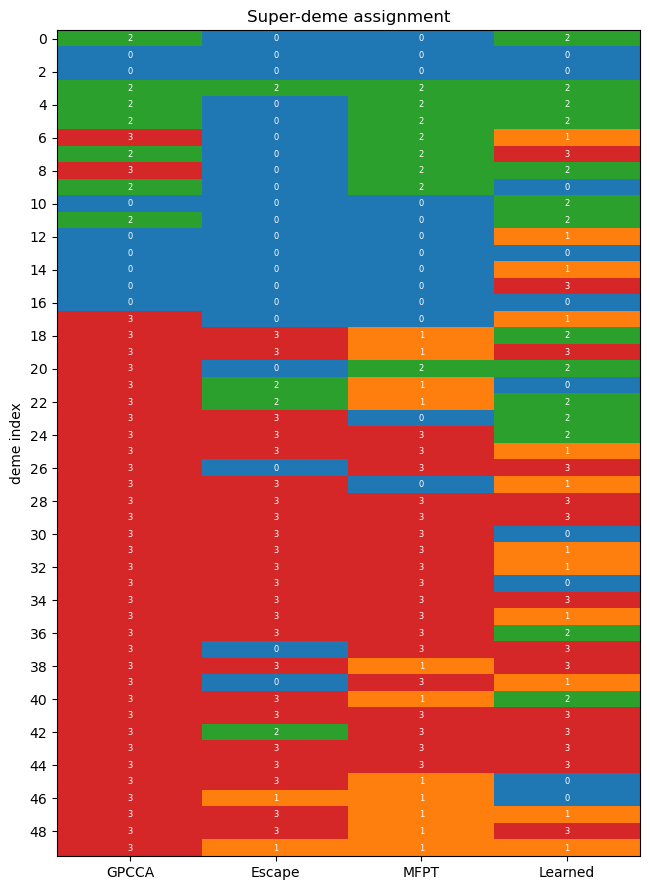

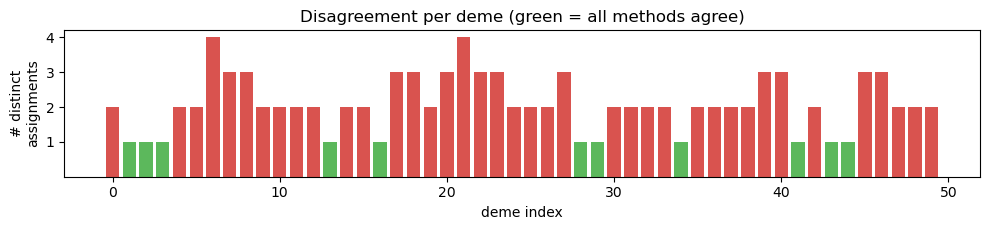


demes where all methods agree: 11/50
demes fully split (all different): 2/50


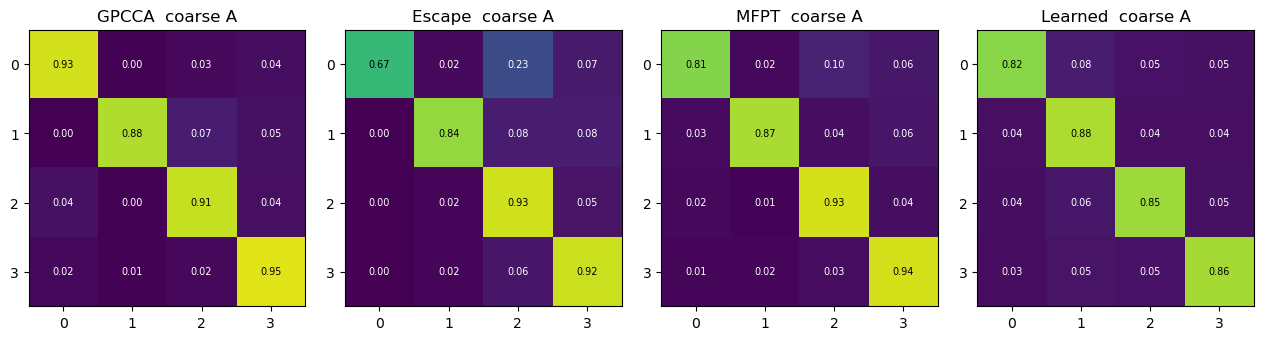


per-cluster self-transition (diagonal of coarse A) — higher = more metastable
  GPCCA   : [np.float64(0.931), np.float64(0.88), np.float64(0.91), np.float64(0.951)]
  Escape  : [np.float64(0.67), np.float64(0.841), np.float64(0.929), np.float64(0.921)]
  MFPT    : [np.float64(0.813), np.float64(0.874), np.float64(0.935), np.float64(0.937)]
  Learned : [np.float64(0.823), np.float64(0.876), np.float64(0.852), np.float64(0.865)]


In [85]:
def align(ref, lbl, m):
    best, best_perm = -1, tuple(range(m))
    for perm in permutations(range(m)):
        mapped = np.array([perm[l] for l in lbl])
        agree = (mapped == ref).mean()
        if agree > best:
            best, best_perm = agree, perm
    return np.array([best_perm[l] for l in lbl]), best

methods = {'GPCCA': lbl_g, 'Escape': lbl_e, 'MFPT': lbl_m}
coarse = {'GPCCA': P_g, 'Escape': P_e, 'MFPT': P_m}
if 'lbl_lin' in dir():
    methods['Learned'] = lbl_lin
    if 'P_lin' in dir():
        coarse['Learned'] = P_lin

ref = lbl_g
aligned = {}
for name, lbl in methods.items():
    a, agr = align(ref, lbl, N_CLUSTERS)
    aligned[name] = a
    print(f"{name:8s} agreement vs GPCCA: {agr:.0%}  "
          f"sizes={[int((a==k).sum()) for k in range(N_CLUSTERS)]}")

names = list(methods.keys())
M_assign = np.array([aligned[n] for n in names]).T   # (50, n_methods)

fig, ax = plt.subplots(figsize=(1.4 * len(names) + 1, 9))
im = ax.imshow(M_assign, aspect='auto', cmap='tab10', vmin=0, vmax=9,
               interpolation='nearest')
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=0)
ax.set_yticks(range(0, 50, 2))
ax.set_ylabel('deme index'); ax.set_title('Super-deme assignment')
# annotate each cell with its cluster id
for i in range(50):
    for j in range(len(names)):
        ax.text(j, i, str(M_assign[i, j]), ha='center', va='center',
                fontsize=6, color='white')
plt.tight_layout(); plt.savefig('assignments_side_by_side.png', dpi=130)
plt.show()


disagree = np.array([len(set(M_assign[i])) for i in range(50)])
fig, ax = plt.subplots(figsize=(10, 2.4))
ax.bar(range(50), disagree, color=['#d9534f' if d > 1 else '#5cb85c' for d in disagree])
ax.set_xlabel('deme index'); ax.set_ylabel('# distinct\nassignments')
ax.set_title('Disagreement per deme (green = all methods agree)')
ax.set_yticks(range(1, len(names) + 1))
plt.tight_layout(); plt.savefig('disagreement_per_deme.png', dpi=130)
plt.show()
print(f"\ndemes where all methods agree: {(disagree==1).sum()}/50")
print(f"demes fully split (all different): {(disagree==len(names)).sum()}/50")


fig, axes = plt.subplots(1, len(coarse), figsize=(3.2 * len(coarse), 3.2))
if len(coarse) == 1:
    axes = [axes]
for ax, (name, P) in zip(axes, coarse.items()):
    im = ax.imshow(P, cmap='viridis', vmin=0, vmax=1)
    ax.set_title(f'{name}  coarse A')
    ax.set_xticks(range(N_CLUSTERS)); ax.set_yticks(range(N_CLUSTERS))
    for i in range(P.shape[0]):
        for j in range(P.shape[1]):
            ax.text(j, i, f'{P[i,j]:.2f}', ha='center', va='center',
                    fontsize=7, color='w' if P[i, j] < 0.6 else 'k')
plt.tight_layout(); plt.savefig('coarse_matrices_side_by_side.png', dpi=130)
plt.show()


print("\nper-cluster self-transition (diagonal of coarse A) — higher = more metastable")
for name, P in coarse.items():
    print(f"  {name:8s}: {[round(P[k,k],3) for k in range(N_CLUSTERS)]}")